In [1]:
# imports
from transformers import AutoProcessor, AutoModelForCausalLM
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torch.nn.functional as F
import os
from tqdm import tqdm
import shutil
import random
import pandas as pd
from glob import glob
import numpy as np
import seaborn as sns
from PIL import Image, ImageFilter, ImageEnhance
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
import cv2
from ultralytics import YOLO
import clip
import re
import copy

# ML / evaluation (fusion classifier)
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score, confusion_matrix
from sklearn.metrics import roc_curve, auc as sk_auc

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Utils
from collections import defaultdict
from typing import List, Dict, Tuple, Optional

In [2]:
# Use GPU if available
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

True
Using device: cuda


In [3]:
clip_model, preprocess = clip.load("ViT-B/32", device=device)

In [4]:
yolo_model = YOLO("yolov8m.pt")

In [5]:
UCF_ROOT = Path(r"UCF Crime Dataset")
SPLIT = "Train"
NORMAL_CLASS = "NormalVideos"

split_dir = UCF_ROOT / SPLIT
print("UCF_ROOT exists:", UCF_ROOT.exists())
print("split_dir exists:", split_dir.exists())
print("classes:", [p.name for p in split_dir.iterdir() if p.is_dir()])

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

UCF_ROOT exists: True
split_dir exists: True
classes: ['Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'NormalVideos', 'RoadAccidents', 'Robbery', 'Shooting', 'Shoplifting', 'Stealing', 'Vandalism']


In [6]:
IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}
_LAST_NUM = re.compile(r"_(\d+)$")  # Abuse001_x264_120 -> 120

def frame_index(p: Path) -> int:
    m = _LAST_NUM.search(p.stem)
    return int(m.group(1)) if m else 0

In [7]:
def list_videos(split_dir: Path):
    items = []
    class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])

    for class_dir in class_dirs:
        video_dirs = sorted([v for v in class_dir.iterdir() if v.is_dir()])
        for video_dir in video_dirs:
            frames = [p for p in video_dir.iterdir()
                      if p.is_file() and p.suffix.lower() in IMG_EXTS]
            if not frames:
                continue
            frames = sorted(frames, key=frame_index)

            items.append({
                "class_name": class_dir.name,
                "video_id": video_dir.name,
                "video_dir": video_dir,
                "frames": frames
            })
    return items

videos = list_videos(split_dir)
print("Total videos:", len(videos))
print("Example item:", videos[0]["class_name"], videos[0]["video_id"], "frames:", len(videos[0]["frames"]))


Total videos: 1610
Example item: Abuse Abuse001_x264 frames: 273


In [8]:
classes = sorted({v["class_name"] for v in videos})
label2idx = {c:i for i,c in enumerate(classes)}
idx2label = {i:c for c,i in label2idx.items()}

print("Classes:", classes)
print("label2idx:", label2idx)


Classes: ['Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'NormalVideos', 'RoadAccidents', 'Robbery', 'Shooting', 'Shoplifting', 'Stealing', 'Vandalism']
label2idx: {'Abuse': 0, 'Arrest': 1, 'Arson': 2, 'Assault': 3, 'Burglary': 4, 'Explosion': 5, 'Fighting': 6, 'NormalVideos': 7, 'RoadAccidents': 8, 'Robbery': 9, 'Shooting': 10, 'Shoplifting': 11, 'Stealing': 12, 'Vandalism': 13}


In [9]:
def uniform_sample_indices(n_frames: int, n_sample: int) -> np.ndarray:
    if n_frames <= 0:
        return np.array([], dtype=int)
    if n_frames >= n_sample:
        return np.linspace(0, n_frames - 1, num=n_sample, dtype=int)
    return np.linspace(0, n_frames - 1, num=n_sample, dtype=int) 


In [10]:
class UCFCrimeVideoDataset(Dataset):
    def __init__(self, video_items, label2idx, n_frames=32, transform=None,
                 return_binary=False, normal_class="NormalVideos"):
        self.video_items = video_items
        self.label2idx = label2idx
        self.n_frames = n_frames
        self.transform = transform
        self.return_binary = return_binary
        self.normal_class = normal_class

    def __len__(self):
        return len(self.video_items)

    def __getitem__(self, i):
        item = self.video_items[i]
        frames = item["frames"]
        idxs = uniform_sample_indices(len(frames), self.n_frames)

        imgs = []
        for k in idxs:
            img = Image.open(frames[int(k)]).convert("RGB")
            if self.transform is not None:
                img = self.transform(img)  # tensor
            imgs.append(img)

        if self.transform is not None:
            x = torch.stack(imgs, dim=0)  # [T,3,H,W]
        else:
            x = imgs  # list of PIL

        class_name = item["class_name"]
        y_multi = self.label2idx[class_name]
        y_bin = 0 if class_name == self.normal_class else 1

        if self.return_binary:
            return x, y_bin, y_multi, item["video_id"], class_name
        return x, y_multi, item["video_id"], class_name


In [11]:
ds = UCFCrimeVideoDataset(
    videos, label2idx,
    n_frames=32,
    transform=preprocess,        
    return_binary=True,
    normal_class=NORMAL_CLASS
)

dl = DataLoader(ds, batch_size=2, shuffle=True, num_workers=0)

In [12]:
@torch.no_grad()
def clip_batch_to_video_vectors(x, clip_model, device):
    """
    Convert a batch of videos (as sampled frames) into one fixed-size CLIP vector per video.

    x: [B, T, 3, 224, 224]
    returns: [B, 2D] where D is CLIP embedding dim (ViT-B/32 usually 512)
    """

    clip_model.eval()  # Set model to evaluation mode (no dropout, stable inference)

    # Unpack input dimensions
    B, T, C, H, W = x.shape

    # Move input to GPU/CPU device
    x = x.to(device)

    # Flatten videos into a single batch of frames:
    # [B, T, 3, 224, 224] -> [B*T, 3, 224, 224]
    xf = x.view(B * T, C, H, W)

    # Encode each frame with CLIP to get an embedding per frame:
    # [B*T, 3, 224, 224] -> [B*T, D]
    feats = clip_model.encode_image(xf)

    # Normalize embeddings to unit length (helps stability and similarity-based learning)
    feats = F.normalize(feats, dim=-1)

    # Reshape back to per-video sequence:
    # [B*T, D] -> [B, T, D]
    D = feats.shape[-1]
    feats = feats.view(B, T, D)

    # Pool over time to get one vector per video:
    # mean pooling captures "overall" content across frames
    v_mean = feats.mean(dim=1)            # [B, D]
    # max pooling captures the strongest signal across frames (useful if anomaly appears briefly)
    k = min(4, T)  
    v_topk = feats.topk(k, dim=1).values.mean(dim=1)      # [B, D]

    # Concatenate mean and max to form the final video representation:
    # [B, D] + [B, D] -> [B, 2D]
    video_vecs = torch.cat([v_mean, v_topk], dim=-1)

    return video_vecs

In [13]:
x, y_bin, y_multi, video_ids, class_names = next(iter(dl))  # Take one batch from DataLoader

video_vecs = clip_batch_to_video_vectors(x, clip_model, device)

print("x shape:", x.shape)                    # Expected: [B, T, 3, 224, 224]
print("video_vecs shape:", video_vecs.shape)  # Expected: [B, 2D] e.g., [2, 1024]
print("video_ids:", video_ids)                # Debug: which video folders were sampled
print("class_names:", class_names)            # Debug: their class names
print("binary:", y_bin)                       # 0=NormalVideos, 1=Anomaly
print("multi:", y_multi)                      # Multiclass label indices

x shape: torch.Size([2, 32, 3, 224, 224])
video_vecs shape: torch.Size([2, 1024])
video_ids: ('Normal_Videos489_x264', 'Robbery062_x264')
class_names: ('NormalVideos', 'Robbery')
binary: tensor([0, 1])
multi: tensor([7, 9])


In [14]:
PROMPTS = [
    "a normal surveillance video",
    "people walking",
    "people running",
    "a fight is happening",
    "a robbery is happening",
    "a car accident is happening",
    "a crowd panic is happening",
]

text_tokens = clip.tokenize(PROMPTS).to(device)

with torch.no_grad():
    text_feat = clip_model.encode_text(text_tokens).float()  # [P, Dt]
    text_feat = text_feat / (text_feat.norm(dim=-1, keepdim=True) + 1e-9)

i = 0
v = video_vecs[i].detach().cpu().float()  # [Dv]
Dv = v.shape[0]
Dt = text_feat.shape[1]

print("Dv (video_vec dim) =", Dv, "| Dt (text dim) =", Dt)

if Dv == 2 * Dt:
    v_mean = v[:Dt]
    v_max  = v[Dt:]
    v = 0.5 * (v_mean + v_max)    # merge back to 512 in a reasonable way

elif Dv == Dt:
    pass

else:
    raise RuntimeError(f"Can't align dims: video D={Dv}, text D={Dt}. "
                       f"Expected D==Dt or D==2*Dt (mean+max concat).")

v = v.to(device)
v = v / (v.norm() + 1e-9)

with torch.no_grad():
    sims = (v @ text_feat.T)  # [P]
    topk = torch.topk(sims, k=min(10, sims.numel()))

print("\n=== CLIP prompt 'transcription' (top matches) ===")
print("video_id:", video_ids[i])
print("GT class:", class_names[i], "| GT binary:", int(y_bin[i]))
for score, idx in zip(topk.values.tolist(), topk.indices.tolist()):
    print(f"{score: .4f} | {PROMPTS[idx]}")


Dv (video_vec dim) = 1024 | Dt (text dim) = 512

=== CLIP prompt 'transcription' (top matches) ===
video_id: Normal_Videos489_x264
GT class: NormalVideos | GT binary: 0
 0.2929 | a normal surveillance video
 0.2642 | people walking
 0.2452 | a car accident is happening
 0.2382 | people running
 0.2272 | a robbery is happening
 0.2260 | a crowd panic is happening
 0.2046 | a fight is happening


In [15]:
@torch.no_grad()
def extract_clip_embeddings_from_loader(dl, clip_model, device):
    clip_model.eval()

    X_list = []
    ybin_list = []
    ymulti_list = []
    vid_list = []
    cname_list = []

    for x, y_bin, y_multi, video_ids, class_names in dl:
        # x: [B, T, 3, 224, 224]
        video_vecs = clip_batch_to_video_vectors(x, clip_model, device)  # [B, 2D]

        # Move to CPU for storage
        X_list.append(video_vecs.cpu())
        ybin_list.append(y_bin.cpu())
        ymulti_list.append(y_multi.cpu())

        # Keep ids/names as python lists
        vid_list.extend(list(video_ids))
        cname_list.extend(list(class_names))

    X_embed = torch.cat(X_list, dim=0)
    y_bin_all = torch.cat(ybin_list, dim=0)
    y_multi_all = torch.cat(ymulti_list, dim=0)

    return X_embed, y_bin_all, y_multi_all, vid_list, cname_list

In [16]:
X_embed, y_bin_all, y_multi_all, vid_list, cname_list = extract_clip_embeddings_from_loader(dl, clip_model, device)

print("X_embed shape:", X_embed.shape)
print("y_bin shape:", y_bin_all.shape, "| positives:", int((y_bin_all == 1).sum()))
print("y_multi shape:", y_multi_all.shape)
print("Example:", vid_list[0], cname_list[0], "bin=", int(y_bin_all[0]), "multi=", int(y_multi_all[0]))

X_embed shape: torch.Size([1610, 1024])
y_bin shape: torch.Size([1610]) | positives: 810
y_multi shape: torch.Size([1610])
Example: Normal_Videos707_x264 NormalVideos bin= 0 multi= 7


In [17]:
torch.save({
    "X_embed": X_embed.cpu(),
    "y_bin": y_bin_all.cpu(),
    "y_multi": y_multi_all.cpu(),
    "video_ids": np.array(vid_list, dtype=object),
    "class_names": np.array(cname_list, dtype=object),
}, "ucf_clip_embeddings_train.pt")
print("Saved ucf_clip_embeddings_train.pt")


Saved ucf_clip_embeddings_train.pt


In [18]:
data = torch.load("ucf_clip_embeddings_train.pt", map_location="cpu")

X_embed = data["X_embed"]          # [N, 1024]
y_bin_all = data["y_bin"]          # [N]
y_multi_all = data["y_multi"]      # [N]
vid_list = data["video_ids"]       # list[str]
cname_list = data["class_names"]   # list[str]

print("Loaded:")
print("X_embed:", X_embed.shape)
print("y_bin:", y_bin_all.shape, "| positives:", int((y_bin_all == 1).sum()))
print("y_multi:", y_multi_all.shape)
print("Example:", vid_list[0], cname_list[0], "bin=", int(y_bin_all[0]), "multi=", int(y_multi_all[0]))

Loaded:
X_embed: torch.Size([1610, 1024])
y_bin: torch.Size([1610]) | positives: 810
y_multi: torch.Size([1610])
Example: Normal_Videos707_x264 NormalVideos bin= 0 multi= 7


In [19]:
# Convert to numpy for splitting
X_np = X_embed.numpy()
y_np = y_bin_all.numpy()

# Stratified split keeps the same anomaly ratio in train and val
X_train, X_val, y_train, y_val = train_test_split(
    X_np, y_np,
    test_size=0.2,
    random_state=42,
    stratify=y_np
)

print("Train:", X_train.shape, "positives:", int(y_train.sum()))
print("Val  :", X_val.shape,   "positives:", int(y_val.sum()))


Train: (1288, 1024) positives: 648
Val  : (322, 1024) positives: 162


In [20]:
# Convert to torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)  # float for BCEWithLogitsLoss

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

train batches: 21
val batches: 2


In [21]:
class BinaryMLP(nn.Module):
    def __init__(self, in_dim=1024, hidden_dim=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)  # [B]


model = BinaryMLP(in_dim=X_train_t.shape[1], hidden_dim=256, dropout=0.3).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)

print(model)


BinaryMLP(
  (net): Sequential(
    (0): Linear(in_features=1024, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [22]:
def train_model(
    model, loader, optimizer, criterion, device,
    epochs=10,
    val_loader=None,
    patience=5,
    save_best_path="best_binary_mlp.pt"
):
    train_losses = []

    best_val_loss = float("inf")
    best_state = None
    bad_epochs = 0

    for ep in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        pbar = tqdm(loader, total=len(loader), desc=f"Train Epoch {ep}/{epochs}", leave=False)

        for Xb, yb in pbar:
            Xb = Xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(Xb)           
            loss = criterion(logits, yb) 
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * Xb.size(0)

            # Update progress bar with current loss
            pbar.set_postfix(loss=float(loss.item()))

        avg_loss = total_loss / len(loader.dataset)
        train_losses.append(avg_loss)

        # Print epoch summary (same as you had)
        msg = f"Epoch {ep:02d}/{epochs} | train_loss={avg_loss:.4f}"

        if val_loader is not None:
            val_loss, _, _ = eval_model(model, val_loader, criterion, device)

            msg += f" | val_loss={val_loss:.4f}"

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = copy.deepcopy(model.state_dict())
                torch.save(best_state, save_best_path)
                bad_epochs = 0
            else:
                bad_epochs += 1
                msg += f" | patience {bad_epochs}/{patience}"

            print(msg)

            if bad_epochs >= patience:
                print(f"Early stopping: no val_loss improvement for {patience} epochs.")
                break
        else:
            print(msg)

    # ---- Added: load best weights back into the model ----
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Loaded best weights | best_val_loss={best_val_loss:.4f} | saved to: {save_best_path}")

    return train_losses


@torch.no_grad()
def eval_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    all_probs = []
    all_y = []

    pbar = tqdm(loader, total=len(loader), desc="Eval", leave=False)

    for Xb, yb in pbar:
        Xb = Xb.to(device)
        yb = yb.to(device)

        logits = model(Xb)
        loss = criterion(logits, yb)

        probs = torch.sigmoid(logits)

        total_loss += loss.item() * Xb.size(0)
        all_probs.append(probs.cpu())
        all_y.append(yb.cpu())

        # Update progress bar with current loss
        pbar.set_postfix(loss=float(loss.item()))

    val_loss = total_loss / len(loader.dataset)
    all_probs = torch.cat(all_probs).numpy()
    all_y = torch.cat(all_y).numpy()

    print(f"Eval | val_loss={val_loss:.4f}")
    return val_loss, all_probs, all_y


In [23]:
train_losses = train_model(
    model, train_loader, optimizer, criterion, device,
    epochs=50,
    val_loader=val_loader,
    patience=7,
    save_best_path="best_binary_mlp.pt"
)

# model is already loaded with best weights
val_loss, val_probs, val_y = eval_model(model, val_loader, criterion, device)


Eval | val_loss=0.6849
Epoch 01/50 | train_loss=0.6909 | val_loss=0.6849


Eval | val_loss=0.6569
Epoch 02/50 | train_loss=0.6768 | val_loss=0.6569


Eval | val_loss=0.5760
Epoch 03/50 | train_loss=0.6272 | val_loss=0.5760


Eval | val_loss=0.4506
Epoch 04/50 | train_loss=0.5183 | val_loss=0.4506


Eval | val_loss=0.4256
Epoch 05/50 | train_loss=0.4190 | val_loss=0.4256


...

Eval | val_loss=0.3438
Epoch 28/50 | train_loss=0.2369 | val_loss=0.3438 | patience 4/7


Eval | val_loss=0.3517
Epoch 29/50 | train_loss=0.2359 | val_loss=0.3517 | patience 5/7


Eval | val_loss=0.3484
Epoch 30/50 | train_loss=0.2438 | val_loss=0.3484 | patience 6/7


Eval | val_loss=0.3496
Epoch 31/50 | train_loss=0.2376 | val_loss=0.3496 | patience 7/7
Early stopping: no val_loss improvement for 7 epochs.
Loaded best weights | best_val_loss=0.3418 | saved to: best_binary_mlp.pt


Eval | val_loss=0.3418


In [24]:
val_pred = (val_probs >= 0.4).astype(int)

acc = accuracy_score(val_y, val_pred)
f1 = f1_score(val_y, val_pred)
cm = confusion_matrix(val_y, val_pred)

print("Accuracy:", acc)
print("F1:", f1)
print("Confusion matrix:\n", cm)
print("\nReport:\n", classification_report(val_y, val_pred, digits=4))


Accuracy: 0.8509316770186336
F1: 0.8545454545454545
Confusion matrix:
 [[133  27]
 [ 21 141]]

Report:
               precision    recall  f1-score   support

         0.0     0.8636    0.8313    0.8471       160
         1.0     0.8393    0.8704    0.8545       162

    accuracy                         0.8509       322
   macro avg     0.8515    0.8508    0.8508       322
weighted avg     0.8514    0.8509    0.8509       322



In [25]:
torch.save(model.state_dict(), "binary_clip_mlp_best.pt")
print("Saved: binary_clip_mlp_best.pt")

Saved: binary_clip_mlp_best.pt


CLIP TEST

In [26]:
# Point to the UNSEEN split
TEST_SPLIT = "Test"
test_split_dir = UCF_ROOT / TEST_SPLIT

print("test_split_dir:", test_split_dir)
print("exists:", test_split_dir.exists())
print("test classes (folders):", [p.name for p in test_split_dir.iterdir() if p.is_dir()])

# List videos from Test
test_videos = list_videos(test_split_dir)
print("Total TEST videos:", len(test_videos))
print("Example:", test_videos[0]["class_name"], test_videos[0]["video_id"], "frames:", len(test_videos[0]["frames"]))


test_split_dir: UCF Crime Dataset\Test
exists: True
test classes (folders): ['Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'NormalVideos', 'RoadAccidents', 'Robbery', 'Shooting', 'Shoplifting', 'Stealing', 'Vandalism']
Total TEST videos: 290
Example: Abuse Abuse028_x264 frames: 142


In [27]:
# Make label2idx safe for any class that exists in Test but not in Train
label2idx_test = dict(label2idx)
next_i = max(label2idx_test.values()) + 1 if len(label2idx_test) else 0

for v in test_videos:
    c = v["class_name"]
    if c not in label2idx_test:
        label2idx_test[c] = next_i
        next_i += 1

# Build TEST dataset/loader (same settings as training)
test_ds = UCFCrimeVideoDataset(
    test_videos,
    label2idx_test,
    n_frames=32,
    transform=preprocess,
    return_binary=True,
    normal_class=NORMAL_CLASS
)

test_dl = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)
print("test batches:", len(test_dl))


test batches: 10


In [28]:
# Extract CLIP video vectors for TEST
X_test_embed, y_test_bin, y_test_multi, test_vid_list, test_cname_list = extract_clip_embeddings_from_loader(
    test_dl, clip_model, device
)

print("X_test_embed:", X_test_embed.shape)
print("y_test_bin:", y_test_bin.shape, "| positives:", int((y_test_bin == 1).sum()))


X_test_embed: torch.Size([290, 1024])
y_test_bin: torch.Size([290]) | positives: 140


In [29]:
# Load your trained CLIP-only binary model
clip_test_model = BinaryMLP(in_dim=X_test_embed.shape[1], hidden_dim=256, dropout=0.3).to(device)
clip_test_model.load_state_dict(torch.load("binary_clip_mlp_best.pt", map_location=device))
clip_test_model.eval()
print("Loaded: binary_clip_mlp_best.pt")

# Predict + metrics
with torch.no_grad():
    logits = clip_test_model(X_test_embed.to(device).float())  # [N]
    probs  = torch.sigmoid(logits).cpu().numpy()               # [N]

y_true = y_test_bin.cpu().numpy().astype(int)
y_pred = (probs >= 0.5).astype(int)

acc = (y_pred == y_true).mean()
cm  = confusion_matrix(y_true, y_pred)

auc = roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else float("nan")
ap  = average_precision_score(y_true, probs) if len(np.unique(y_true)) > 1 else float("nan")

print(f"\nTEST RESULTS (CLIP-only) | Acc={acc:.4f} | ROC-AUC={auc:.4f} | PR-AUC={ap:.4f}")
print("Confusion matrix [[TN FP],[FN TP]]:\n", cm)
print("\nReport:\n", classification_report(y_true, y_pred, target_names=["Normal(0)", "Anomaly(1)"]))


Loaded: binary_clip_mlp_best.pt

TEST RESULTS (CLIP-only) | Acc=0.8621 | ROC-AUC=0.9259 | PR-AUC=0.9117
Confusion matrix [[TN FP],[FN TP]]:
 [[136  14]
 [ 26 114]]

Report:
               precision    recall  f1-score   support

   Normal(0)       0.84      0.91      0.87       150
  Anomaly(1)       0.89      0.81      0.85       140

    accuracy                           0.86       290
   macro avg       0.87      0.86      0.86       290
weighted avg       0.86      0.86      0.86       290



In [30]:
df = pd.DataFrame({
    "video_id": test_vid_list,
    "class_name": test_cname_list,
    "y_true": y_true,
    "prob_anomaly": probs,
})
df["y_pred"] = (df["prob_anomaly"] >= 0.5).astype(int)
df["wrong"]  = (df["y_pred"] != df["y_true"])

fp = df[(df["wrong"]) & (df["y_true"] == 0)].sort_values("prob_anomaly", ascending=False).head(15)
fn = df[(df["wrong"]) & (df["y_true"] == 1)].sort_values("prob_anomaly", ascending=True).head(15)

print("\nTop False Positives (Normal predicted as Anomaly):")
display(fp)

print("\nTop False Negatives (Anomaly predicted as Normal):")
display(fn)



Top False Positives (Normal predicted as Anomaly):


,video_id,class_name,y_true,prob_anomaly,y_pred,wrong
189,Normal_Videos_925_x264,NormalVideos,0,0.970891,1,True
158,Normal_Videos_887_x264,NormalVideos,0,0.964444,1,True
149,Normal_Videos_878_x264,NormalVideos,0,0.956445,1,True
172,Normal_Videos_901_x264,NormalVideos,0,0.945654,1,True
125,Normal_Videos_725_x264,NormalVideos,0,0.926789,1,True
109,Normal_Videos_478_x264,NormalVideos,0,0.926626,1,True
61,Normal_Videos_014_x264,NormalVideos,0,0.869823,1,True
155,Normal_Videos_884_x264,NormalVideos,0,0.869358,1,True
60,Normal_Videos_010_x264,NormalVideos,0,0.819398,1,True
86,Normal_Videos_189_x264,NormalVideos,0,0.817637,1,True



Top False Negatives (Anomaly predicted as Normal):


,video_id,class_name,y_true,prob_anomaly,y_pred,wrong
277,Shoplifting039_x264,Shoplifting,1,0.013355,0,True
274,Shoplifting033_x264,Shoplifting,1,0.020557,0,True
37,Explosion011_x264,Explosion,1,0.039142,0,True
6,Arrest039_x264,Arrest,1,0.069496,0,True
53,Fighting003_x264,Fighting,1,0.080641,0,True
215,RoadAccidents016_x264,RoadAccidents,1,0.105981,0,True
29,Burglary076_x264,Burglary,1,0.107318,0,True
258,Shooting048_x264,Shooting,1,0.129752,0,True
251,Shooting032_x264,Shooting,1,0.150237,0,True
223,RoadAccidents123_x264,RoadAccidents,1,0.183622,0,True


y_true shape: (290,) probs shape: (290,)


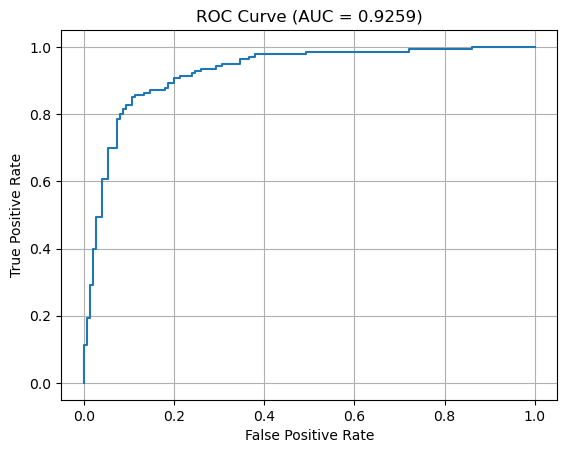

In [31]:
print("y_true shape:", np.shape(y_true), "probs shape:", np.shape(probs))

# ROC curve
fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc_val = roc_auc_score(y_true, probs)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc_val:.4f})")
plt.grid(True)
plt.show()



YOLO

In [32]:
# Build model skeleton
clip_trained_model = BinaryMLP(in_dim=1024, hidden_dim=256, dropout=0.2).to(device)

# Load weights (state_dict)
state = torch.load("binary_clip_mlp_best.pt", map_location="cpu")

# If the file is a full checkpoint dict, handle that too
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]

clip_trained_model.load_state_dict(state)
clip_trained_model.eval()

print("Loaded BinaryMLP weights from: binary_clip_mlp_best.pt")
print("Model is ready on device:", device)


Loaded BinaryMLP weights from: binary_clip_mlp_best.pt
Model is ready on device: cuda


In [33]:
# X_embed_all: [1610, 1024] (from your saved embeddings file)
data = torch.load("ucf_clip_embeddings_train.pt", map_location="cpu")
X_embed_all = data["X_embed"]

with torch.no_grad():
    logits = clip_trained_model(X_embed_all[:8].to(device).float())
    probs = torch.sigmoid(logits).cpu()

print("probs:", probs.numpy())


probs: [   0.055854      0.9045     0.58191     0.76588     0.97983     0.97788     0.14628     0.11537]


In [34]:
PERSON_ID = 0
VEHICLE_IDS = {1, 2, 3, 5, 7}  # bicycle, car, motorcycle, bus, truck

def sample_uniform(paths, n=32):
    """Return up to n paths sampled uniformly from the list."""
    if len(paths) <= n:
        return list(paths)
    idx = np.linspace(0, len(paths) - 1, n).round().astype(int)
    return [paths[i] for i in idx]

def yolo_video_features_from_paths(frame_paths, yolo_model, device, imgsz=640, conf=0.25):
    """
    YOLO detection-based features per video.

    Returns K=16 features:
      0 mean_people, 1 max_people, 2 std_people
      3 mean_delta_people, 4 max_delta_people
      5 mean_total, 6 max_total, 7 std_total
      8 mean_conf, 9 max_conf, 10 std_conf
      11 mean_area_ratio, 12 max_area_ratio, 13 std_area_ratio
      14 mean_person_area_ratio, 15 max_person_area_ratio
    """
    K = 16
    if len(frame_paths) == 0:
        return np.zeros(K, dtype=np.float32)

    results = yolo_model.predict(
        source=[str(p) for p in frame_paths],
        imgsz=imgsz,
        conf=conf,
        device=device,
        verbose=False
    )

    people_counts, total_counts = [], []
    conf_means, area_ratios = [], []
    person_area_ratios = []

    for r in results:
        boxes = r.boxes
        if boxes is None or boxes.xyxy is None or len(boxes) == 0:
            people_counts.append(0)
            total_counts.append(0)
            conf_means.append(0.0)
            area_ratios.append(0.0)
            person_area_ratios.append(0.0)
            continue

        cls = boxes.cls.detach().cpu().numpy().astype(int)
        confs = boxes.conf.detach().cpu().numpy()
        xyxy = boxes.xyxy.detach().cpu().numpy()

        H, W = r.orig_shape
        frame_area = (H * W + 1e-9)

        # counts
        people = int((cls == PERSON_ID).sum())
        total  = int(len(cls))
        people_counts.append(people)
        total_counts.append(total)

        # conf
        conf_means.append(float(confs.mean()) if len(confs) else 0.0)

        # total area ratio (all dets)
        areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
        area_ratios.append(float(areas.sum() / frame_area))

        # person-only area ratio
        mask_p = (cls == PERSON_ID)
        if mask_p.any():
            xy_p = xyxy[mask_p]
            areas_p = (xy_p[:, 2] - xy_p[:, 0]) * (xy_p[:, 3] - xy_p[:, 1])
            person_area_ratios.append(float(areas_p.sum() / frame_area))
        else:
            person_area_ratios.append(0.0)

    people_counts = np.array(people_counts, dtype=np.float32)
    total_counts  = np.array(total_counts, dtype=np.float32)
    conf_means    = np.array(conf_means, dtype=np.float32)
    area_ratios   = np.array(area_ratios, dtype=np.float32)
    person_area_ratios = np.array(person_area_ratios, dtype=np.float32)

    # deltas (dynamic change)
    if len(people_counts) >= 2:
        d_people = np.abs(np.diff(people_counts))
        mean_d_people = float(d_people.mean())
        max_d_people  = float(d_people.max())
    else:
        mean_d_people = 0.0
        max_d_people  = 0.0

    feat = np.array([
        float(people_counts.mean()), float(people_counts.max()), float(people_counts.std()),
        mean_d_people, max_d_people,
        float(total_counts.mean()),  float(total_counts.max()),  float(total_counts.std()),
        float(conf_means.mean()),    float(conf_means.max()),    float(conf_means.std()),
        float(area_ratios.mean()),   float(area_ratios.max()),   float(area_ratios.std()),
        float(person_area_ratios.mean()), float(person_area_ratios.max()),
    ], dtype=np.float32)

    return feat


In [35]:
v = videos[0]  # or any videos[i]
frame_paths = sample_uniform(v["frames"], n=32)

feat = yolo_video_features_from_paths(frame_paths, yolo_model, device=device)

print("video_id:", v["video_id"], "| class:", v["class_name"])
print("num sampled frames:", len(frame_paths))
print("YOLO feature vector (len={}):".format(len(feat)), feat)


video_id: Abuse001_x264 | class: Abuse
num sampled frames: 32
YOLO feature vector (len=16): [    0.09375           1     0.29148     0.19355           1     0.15625           1     0.36309    0.053699     0.44466      0.1291   0.0031876    0.029771   0.0077758   0.0018082    0.024888]


In [36]:
X_yolo = []
yolo_vids = []
yolo_classes = []
yolo_ybin = []
yolo_ymulti = []

for v in tqdm(videos, desc="Extract YOLO features", total=len(videos)):
    frame_paths = sample_uniform(v["frames"], n=32)

    feat = yolo_video_features_from_paths(
        frame_paths,
        yolo_model,
        device=device,   # keep your existing device
        imgsz=640,
        conf=0.25
    )

    X_yolo.append(feat)
    yolo_vids.append(v["video_id"])
    yolo_classes.append(v["class_name"])

    yolo_ybin.append(0 if v["class_name"] == NORMAL_CLASS else 1)
    yolo_ymulti.append(label2idx[v["class_name"]])

X_yolo = torch.tensor(np.stack(X_yolo), dtype=torch.float32)

yolo_pack = {
    "X_yolo": X_yolo,                              # [N, 10]
    "video_ids": np.array(yolo_vids, dtype=object),
    "class_names": np.array(yolo_classes, dtype=object),
    "y_bin": torch.tensor(yolo_ybin, dtype=torch.long),
    "y_multi": torch.tensor(yolo_ymulti, dtype=torch.long),
}

torch.save(yolo_pack, "ucf_yolo_features_train_k.pt")
print("Saved: ucf_yolo_features_train_k.pt | X_yolo shape:", X_yolo.shape)


Extract YOLO features: 100%|██████████| 1610/1610 [18:09<00:00,  1.48it/s]

Saved: ucf_yolo_features_train_k.pt | X_yolo shape: torch.Size([1610, 16])


In [38]:
clip_data = torch.load("ucf_clip_embeddings_train.pt", map_location="cpu")
yolo_data = torch.load("ucf_yolo_features_train_k.pt", map_location="cpu")

print("Loaded CLIP keys:", clip_data.keys())
print("Loaded YOLO keys:", yolo_data.keys())


Loaded CLIP keys: dict_keys(['X_embed', 'y_bin', 'y_multi', 'video_ids', 'class_names'])
Loaded YOLO keys: dict_keys(['X_yolo', 'video_ids', 'class_names', 'y_bin', 'y_multi'])


In [39]:
# CLIP
X_embed_all = clip_data["X_embed"].float()       # [N, 1024]
y_bin_all   = clip_data["y_bin"].long()          # [N]
vid_all     = clip_data["video_ids"]             # (N,)

# YOLO
X_yolo_all  = yolo_data["X_yolo"].float()        # [N, k]
vid_yolo    = yolo_data["video_ids"]             # (N,)

print("X_embed_all:", X_embed_all.shape)
print("y_bin_all  :", y_bin_all.shape)
print("X_yolo_all :", X_yolo_all.shape)
print("vid_all len:", len(vid_all))
print("vid_yolo len:", len(vid_yolo))

X_embed_all: torch.Size([1610, 1024])
y_bin_all  : torch.Size([1610])
X_yolo_all : torch.Size([1610, 16])
vid_all len: 1610
vid_yolo len: 1610


In [40]:
idx_yolo = {vid_yolo[i]: i for i in range(len(vid_yolo))}

N = len(vid_all)
K = X_yolo_all.shape[1]

yolo_aligned = torch.zeros((N, K), dtype=torch.float32)
missing = 0

for i, vid in enumerate(vid_all):
    j = idx_yolo.get(vid, None)
    if j is None:
        missing += 1
    else:
        yolo_aligned[i] = X_yolo_all[j].float()

print("yolo_aligned:", yolo_aligned.shape)
print("missing alignments:", missing)


yolo_aligned: torch.Size([1610, 16])
missing alignments: 0


In [42]:
X_fusion_all = torch.cat([X_embed_all, yolo_aligned], dim=1)  # [N, 1034]
print("fusion dim:", X_embed_all.shape[1] + yolo_aligned.shape[1])


fusion dim: 1040


In [43]:
idx = np.arange(len(y_bin_all))

train_idx, val_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=42,
    stratify=y_bin_all.numpy()
)

print("train size:", len(train_idx))
print("val size  :", len(val_idx))

train size: 1288
val size  : 322


In [44]:
Xf_train = X_fusion_all[train_idx].float()
yf_train = y_bin_all[train_idx].float()   # float for BCEWithLogitsLoss

Xf_val   = X_fusion_all[val_idx].float()
yf_val   = y_bin_all[val_idx].float()

train_ds = TensorDataset(Xf_train, yf_train)
val_ds   = TensorDataset(Xf_val, yf_val)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False)

print("Fusion Train:", Xf_train.shape, "positives:", int((yf_train == 1).sum()))
print("Fusion Val  :", Xf_val.shape,   "positives:", int((yf_val == 1).sum()))

Fusion Train: torch.Size([1288, 1040]) positives: 648
Fusion Val  : torch.Size([322, 1040]) positives: 162


In [45]:
# ===== DEBUG: make sure dims match =====
print("X_fusion_all:", X_fusion_all.shape)
print("Xf_train:", Xf_train.shape)
print("One batch Xb:", next(iter(train_loader))[0].shape)

in_dim = next(iter(train_loader))[0].shape[1]
print("Using in_dim from loader:", in_dim)

# Recreate fusion_model to match the loader dimension
fusion_model = BinaryMLP(in_dim=in_dim, hidden_dim=256, dropout=0.2).to(device)

# (re)create optimizer after recreating the model
optimizer = torch.optim.AdamW(fusion_model.parameters(), lr=1e-3, weight_decay=1e-4)

print("fusion_model first layer weight:", fusion_model.net[0].weight.shape)


X_fusion_all: torch.Size([1610, 1040])
Xf_train: torch.Size([1288, 1040])
One batch Xb: torch.Size([64, 1040])
Using in_dim from loader: 1040
fusion_model first layer weight: torch.Size([256, 1040])


In [46]:
train_model(
    fusion_model,
    train_loader,
    optimizer,
    criterion,
    device,
    epochs=50,
    val_loader=val_loader,
    patience=7,
    save_best_path="best_fusion_binary_mlp.pt"
)

Eval | val_loss=0.5529
Epoch 01/50 | train_loss=0.6543 | val_loss=0.5529


Eval | val_loss=0.4200
Epoch 02/50 | train_loss=0.4642 | val_loss=0.4200


Eval | val_loss=0.3963
Epoch 03/50 | train_loss=0.4011 | val_loss=0.3963


Eval | val_loss=0.3913
Epoch 04/50 | train_loss=0.3747 | val_loss=0.3913


Eval | val_loss=0.3749
Epoch 05/50 | train_loss=0.3705 | val_loss=0.3749


...

Eval | val_loss=0.3393
Epoch 22/50 | train_loss=0.1759 | val_loss=0.3393 | patience 4/7


Eval | val_loss=0.3384
Epoch 23/50 | train_loss=0.1725 | val_loss=0.3384 | patience 5/7


Eval | val_loss=0.3723
Epoch 24/50 | train_loss=0.1498 | val_loss=0.3723 | patience 6/7


Eval | val_loss=0.3828
Epoch 25/50 | train_loss=0.1491 | val_loss=0.3828 | patience 7/7
Early stopping: no val_loss improvement for 7 epochs.
Loaded best weights | best_val_loss=0.3362 | saved to: best_fusion_binary_mlp.pt


[0.654330166970721,
 0.4642024506693301,
 0.401096334275992,
 0.37471591482251326,
 0.3705131989088118,
 0.36326806293511243,
 0.3611169475946367,
 0.34427600950928205,
 0.30932238975667065,
 0.30554958465306653,
 0.29002701273616055,
 0.29386689240888036,
 0.26075972755503213,
 0.26089207559638883,
 0.23493789525135703,
 0.22028086755586707,
 0.2207317891883554,
 0.24044390198606883,
 0.2478477735512005,
 0.19454801973441374,
 0.1825188467776553,
 0.17588461130302144,
 0.17252110902752196,
 0.14980959249024065,
 0.14914288459727482]

In [47]:
@torch.no_grad()
def predict_probs(model, X, device):
    model.eval()
    logits = model(X.to(device).float())
    return torch.sigmoid(logits).cpu().numpy()

# Fusion predictions on VAL
fusion_probs = predict_probs(fusion_model, Xf_val, device)
fusion_pred  = (fusion_probs >= 0.4).astype(int)
y_true       = yf_val.cpu().numpy().astype(int)

print("FUSION Accuracy:", accuracy_score(y_true, fusion_pred))
print("FUSION F1:", f1_score(y_true, fusion_pred))
print("FUSION Confusion:\n", confusion_matrix(y_true, fusion_pred))
print(classification_report(y_true, fusion_pred, digits=4))

FUSION Accuracy: 0.860248447204969
FUSION F1: 0.8680351906158358
FUSION Confusion:
 [[129  31]
 [ 14 148]]
              precision    recall  f1-score   support

           0     0.9021    0.8063    0.8515       160
           1     0.8268    0.9136    0.8680       162

    accuracy                         0.8602       322
   macro avg     0.8645    0.8599    0.8598       322
weighted avg     0.8642    0.8602    0.8598       322



TEST YOLO

In [48]:
TEST_SPLIT = "Test"
test_split_dir = UCF_ROOT / TEST_SPLIT

print("test_split_dir:", test_split_dir)
print("exists:", test_split_dir.exists())
print("folders:", [p.name for p in test_split_dir.iterdir() if p.is_dir()])

test_videos = list_videos(test_split_dir)
print("Total TEST videos:", len(test_videos))
print("Example:", test_videos[0]["class_name"], test_videos[0]["video_id"], "frames:", len(test_videos[0]["frames"]))


test_split_dir: UCF Crime Dataset\Test
exists: True
folders: ['Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'NormalVideos', 'RoadAccidents', 'Robbery', 'Shooting', 'Shoplifting', 'Stealing', 'Vandalism']
Total TEST videos: 290
Example: Abuse Abuse028_x264 frames: 142


In [49]:
X_yolo_test = []
test_vids = []
test_classes = []
y_test_bin = []

N_FRAMES = 32

for v in tqdm(test_videos, desc="YOLO features (TEST)", total=len(test_videos)):
    frames = v["frames"]
    if len(frames) == 0:
        continue  

    frame_paths = sample_uniform(frames, n=N_FRAMES)

    feat = yolo_video_features_from_paths(
        frame_paths,
        yolo_model,
        device=device,
        imgsz=640,
        conf=0.25
    )  # expected shape: (10,)

    X_yolo_test.append(feat)
    test_vids.append(v["video_id"])
    test_classes.append(v["class_name"])
    y_test_bin.append(0 if v["class_name"] == NORMAL_CLASS else 1)

X_yolo_test = torch.tensor(np.stack(X_yolo_test), dtype=torch.float32)  # [N,10]
y_test_bin_t = torch.tensor(y_test_bin, dtype=torch.long)              # [N]

print("X_yolo_test:", X_yolo_test.shape)
print("y_test_bin:", y_test_bin_t.shape, "| positives:", int((y_test_bin_t == 1).sum()))


YOLO features (TEST): 100%|██████████| 290/290 [02:51<00:00,  1.69it/s]

X_yolo_test: torch.Size([290, 16])
y_test_bin: torch.Size([290]) | positives: 140


In [50]:
torch.save(
    {
        "X_yolo": X_yolo_test,
        "video_ids": np.array(test_vids, dtype=object),
        "class_names": np.array(test_classes, dtype=object),
        "y_bin": y_test_bin_t,
    },
    "ucf_yolo_features_test.pt"
)

print("Saved: ucf_yolo_features_test.pt")


Saved: ucf_yolo_features_test.pt


In [51]:
yolo_test = torch.load("ucf_yolo_features_test.pt", map_location="cpu")
X_yolo_test = yolo_test["X_yolo"].float()
y_test_bin_t = yolo_test["y_bin"].long()
print(X_yolo_test.shape, y_test_bin_t.shape)


torch.Size([290, 16]) torch.Size([290])


In [52]:
# pick the CLIP test video_ids variable that exists
if "test_vid_list" in globals():
    clip_vids = list(test_vid_list)
elif "test_vids" in globals():
    clip_vids = list(test_vids)
else:
    raise RuntimeError("Run your CLIP TEST cell first (need test_vid_list or test_vids).")

# binary labels from CLIP test
if "y_test_bin" in globals():
    y_true = y_test_bin
elif "y_test_bin_t" in globals():
    y_true = y_test_bin_t
else:
    raise RuntimeError("Run your CLIP TEST cell first (need y_test_bin or y_test_bin_t).")

# normalize y_true to numpy int
if torch.is_tensor(y_true):
    y_true = y_true.detach().cpu().numpy()
else:
    y_true = np.asarray(y_true)
y_true = y_true.astype(int)

# load YOLO test pack
yolo_test = torch.load("ucf_yolo_features_test.pt", map_location="cpu")

X_yolo_all = yolo_test["X_yolo"].float()         # [N, K]
vid_yolo   = list(yolo_test["video_ids"])        # video ids for yolo rows

# align YOLO rows to CLIP order (by video_id)
idx_yolo = {vid_yolo[i]: i for i in range(len(vid_yolo))}

K = X_yolo_all.shape[1]  # YOLO feature dim (dynamic)

yolo_aligned = []
missing = 0

for vid in clip_vids:
    j = idx_yolo.get(vid, None)
    if j is None:
        missing += 1
        yolo_aligned.append(np.zeros((K,), dtype=np.float32))
    else:
        yolo_aligned.append(X_yolo_all[j].cpu().numpy())

yolo_aligned = torch.tensor(np.stack(yolo_aligned), dtype=torch.float32)  # [N, K]

print("X_test_embed:", X_test_embed.shape)  # [N, 1024]
print("yolo_aligned:", yolo_aligned.shape, "| missing:", missing)  # [N, K]

# fusion input: concatenate (not sum)
X_fusion_test = torch.cat([X_test_embed.cpu().float(), yolo_aligned], dim=1)  # [N, 1024+K]
print("X_fusion_test:", X_fusion_test.shape)


X_test_embed: torch.Size([290, 1024])
yolo_aligned: torch.Size([290, 16]) | missing: 0
X_fusion_test: torch.Size([290, 1040])


In [53]:
# load trained fusion model (same as your training cell)
fusion_model = BinaryMLP(in_dim=X_fusion_test.shape[1], hidden_dim=256, dropout=0.2).to(device)
fusion_model.load_state_dict(torch.load("best_fusion_binary_mlp.pt", map_location=device))
fusion_model.eval()

with torch.no_grad():
    logits = fusion_model(X_fusion_test.to(device))
    probs = torch.sigmoid(logits).cpu().numpy()

# same threshold you used for fusion in the notebook
TH = 0.6
pred = (probs >= TH).astype(int)

acc = (pred == y_true).mean()
cm  = confusion_matrix(y_true, pred)
auc = roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else float("nan")
ap  = average_precision_score(y_true, probs) if len(np.unique(y_true)) > 1 else float("nan")

print(f"FUSION TEST | TH={TH} | Acc={acc:.4f} | ROC-AUC={auc:.4f} | PR-AUC={ap:.4f}")
print("Confusion matrix [[TN FP],[FN TP]]:\n", cm)
print("\nReport:\n", classification_report(y_true, pred, target_names=["Normal(0)", "Anomaly(1)"]))


FUSION TEST | TH=0.6 | Acc=0.8828 | ROC-AUC=0.9427 | PR-AUC=0.9344
Confusion matrix [[TN FP],[FN TP]]:
 [[136  14]
 [ 20 120]]

Report:
               precision    recall  f1-score   support

   Normal(0)       0.87      0.91      0.89       150
  Anomaly(1)       0.90      0.86      0.88       140

    accuracy                           0.88       290
   macro avg       0.88      0.88      0.88       290
weighted avg       0.88      0.88      0.88       290



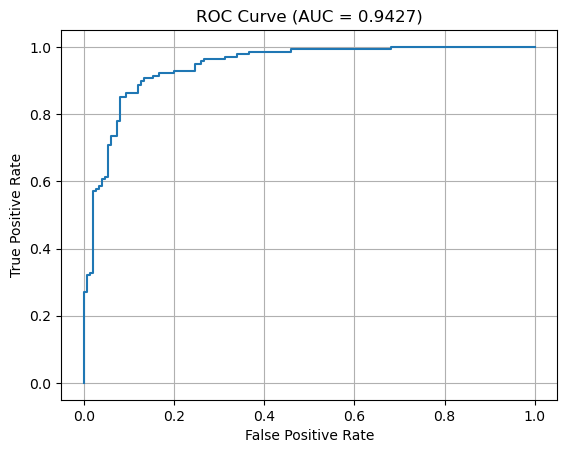

In [54]:
fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = sk_auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.grid(True)
plt.show()


more models

In [61]:
# ===== Baseline Experiments (run on BOTH: CLIP-only and FUSION) =====

import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, accuracy_score, classification_report, confusion_matrix
)

# --- make sure these exist from your notebook ---
# X_embed_all: torch.Tensor [N,1024]
# X_fusion_all: torch.Tensor [N,1034]
# y_bin_all: torch.Tensor [N]
Xe = X_embed_all.detach().cpu().numpy()
Xf = X_fusion_all.detach().cpu().numpy()
y  = y_bin_all.detach().cpu().numpy().astype(int)

# One consistent split for fair comparison
idx = np.arange(len(y))
idx_tr, idx_va = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)

Xe_tr, Xe_va = Xe[idx_tr], Xe[idx_va]
Xf_tr, Xf_va = Xf[idx_tr], Xf[idx_va]
y_tr,  y_va  = y[idx_tr],  y[idx_va]

def eval_probs(name, probs, y_true, thr=0.5):
    preds = (probs >= thr).astype(int)
    out = {
        "name": name,
        "AUC_ROC": roc_auc_score(y_true, probs),
        "AUC_PR":  average_precision_score(y_true, probs),
        "F1":      f1_score(y_true, preds),
        "ACC":     accuracy_score(y_true, preds),
        "CM":      confusion_matrix(y_true, preds),
    }
    return out

results = []

# ===== Experiment 2: Logistic Regression =====
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

lr.fit(Xe_tr, y_tr)
p = lr.predict_proba(Xe_va)[:, 1]
results.append(eval_probs("CLIP | LogisticRegression", p, y_va, thr=0.5))

lr.fit(Xf_tr, y_tr)
p = lr.predict_proba(Xf_va)[:, 1]
results.append(eval_probs("FUSION | LogisticRegression", p, y_va, thr=0.5))


# ===== Experiment 3: Linear SVM (Calibrated -> probabilities) =====
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", max_iter=20000),
        method="sigmoid",
        cv=3
    ))
])

svm.fit(Xe_tr, y_tr)
p = svm.predict_proba(Xe_va)[:, 1]
results.append(eval_probs("CLIP | Calibrated LinearSVM", p, y_va, thr=0.5))

svm.fit(Xf_tr, y_tr)
p = svm.predict_proba(Xf_va)[:, 1]
results.append(eval_probs("FUSION | Calibrated LinearSVM", p, y_va, thr=0.5))


# ===== Experiment 4: HistGradientBoosting (no scaling needed) =====
# Note: class_weight isn't directly supported; we keep it simple here.
hgb = HistGradientBoostingClassifier(
    max_depth=None,
    learning_rate=0.1,
    max_iter=300,
    random_state=42
)

hgb.fit(Xe_tr, y_tr)
p = hgb.predict_proba(Xe_va)[:, 1]
results.append(eval_probs("CLIP | HistGradientBoosting", p, y_va, thr=0.5))

hgb.fit(Xf_tr, y_tr)
p = hgb.predict_proba(Xf_va)[:, 1]
results.append(eval_probs("FUSION | HistGradientBoosting", p, y_va, thr=0.5))


# ---- Pretty print ----
import pandas as pd

rows = []
for r in results:
    tn, fp = r["CM"][0]
    fn, tp = r["CM"][1]
    rows.append({
        "Model": r["name"],
        "AUC_ROC": round(r["AUC_ROC"], 4),
        "AUC_PR": round(r["AUC_PR"], 4),
        "F1": round(r["F1"], 4),
        "ACC": round(r["ACC"], 4),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    })

df_results = pd.DataFrame(rows).sort_values(["AUC_ROC","AUC_PR","F1"], ascending=False)
df_results



,Model,AUC_ROC,AUC_PR,F1,ACC,TN,FP,FN,TP
5,FUSION | HistGradientBoosting,0.9464,0.9454,0.8720,0.8696,137,23,19,143
4,CLIP | HistGradientBoosting,0.9446,0.9432,0.8758,0.8758,141,19,21,141
3,FUSION | Calibrated LinearSVM,0.9179,0.9272,0.8537,0.8478,130,30,19,143
2,CLIP | Calibrated LinearSVM,0.9174,0.9293,0.8554,0.8509,132,28,20,142
1,FUSION | LogisticRegression,0.9035,0.9078,0.8218,0.8168,127,33,26,136
0,CLIP | LogisticRegression,0.9025,0.9079,0.8168,0.8106,125,35,26,136


In [60]:
import pandas as pd

rows = []
for r in results:
    if "HistGradientBoosting" in r["name"]:
        tn, fp = r["CM"][0]
        fn, tp = r["CM"][1]
        rows.append({
            "Model": r["name"],
            "AUC_ROC": round(r["AUC_ROC"], 4),
            "AUC_PR": round(r["AUC_PR"], 4),
            "F1": round(r["F1"], 4),
            "ACC": round(r["ACC"], 4),
            "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)
        })

df_hgb = pd.DataFrame(rows).sort_values("AUC_ROC", ascending=False)
df_hgb


,Model,AUC_ROC,AUC_PR,F1,ACC,TN,FP,FN,TP
1,FUSION | HistGradientBoosting,0.9464,0.9454,0.8720,0.8696,137,23,19,143
0,CLIP | HistGradientBoosting,0.9446,0.9432,0.8758,0.8758,141,19,21,141


trees

In [57]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

rf.fit(Xe_tr, y_tr)
p = rf.predict_proba(Xe_va)[:, 1]
r1 = eval_probs("CLIP | RandomForest", p, y_va, thr=0.5)
print("\n" + "="*70)
print(r1["name"])
print(f"AUC_ROC={r1['AUC_ROC']:.4f} | AUC_PR={r1['AUC_PR']:.4f} | F1={r1['F1']:.4f} | ACC={r1['ACC']:.4f}")
print("Confusion Matrix:\n", r1["CM"])

rf.fit(Xf_tr, y_tr)
p = rf.predict_proba(Xf_va)[:, 1]
r2 = eval_probs("FUSION | RandomForest", p, y_va, thr=0.5)
print("\n" + "="*70)
print(r2["name"])
print(f"AUC_ROC={r2['AUC_ROC']:.4f} | AUC_PR={r2['AUC_PR']:.4f} | F1={r2['F1']:.4f} | ACC={r2['ACC']:.4f}")
print("Confusion Matrix:\n", r2["CM"])



CLIP | RandomForest
AUC_ROC=0.9265 | AUC_PR=0.9224 | F1=0.8464 | ACC=0.8478
Confusion Matrix:
 [[138  22]
 [ 27 135]]

FUSION | RandomForest
AUC_ROC=0.9268 | AUC_PR=0.9211 | F1=0.8418 | ACC=0.8447
Confusion Matrix:
 [[139  21]
 [ 29 133]]


In [ ]:
import numpy as np
import pandas as pd
import torch

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score, confusion_matrix

def eval_probs(name, probs, y_true, thr=0.5):
    probs = np.asarray(probs).reshape(-1)
    y_true = np.asarray(y_true).astype(int)
    pred = (probs >= thr).astype(int)
    return {
        "Model": name,
        "TH": thr,
        "ACC": accuracy_score(y_true, pred),
        "F1": f1_score(y_true, pred),
        "ROC_AUC": roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else np.nan,
        "PR_AUC": average_precision_score(y_true, probs) if len(np.unique(y_true)) > 1 else np.nan,
        "TN": confusion_matrix(y_true, pred)[0,0],
        "FP": confusion_matrix(y_true, pred)[0,1],
        "FN": confusion_matrix(y_true, pred)[1,0],
        "TP": confusion_matrix(y_true, pred)[1,1],
    }

# --- numpy versions ---
Xe_tr = X_embed_all.detach().cpu().numpy()
Xf_tr = X_fusion_all.detach().cpu().numpy()
y_tr  = y_bin_all.detach().cpu().numpy().astype(int)

Xe_te = X_test_embed.detach().cpu().numpy()
Xf_te = X_fusion_test.detach().cpu().numpy()
y_te  = np.asarray(y_true).astype(int)

rows = []

# ===== 1) MLP (load trained) - CLIP =====
clip_mlp = BinaryMLP(in_dim=Xe_te.shape[1], hidden_dim=256, dropout=0.2).to(device)
clip_mlp.load_state_dict(torch.load("binary_clip_mlp_best.pt", map_location=device))
clip_mlp.eval()
with torch.no_grad():
    p = torch.sigmoid(clip_mlp(torch.tensor(Xe_te, dtype=torch.float32, device=device))).cpu().numpy()
rows.append(eval_probs("CLIP | MLP (saved)", p, y_te, thr=0.5))

# ===== 2) MLP (load trained) - FUSION =====
fus_mlp = BinaryMLP(in_dim=Xf_te.shape[1], hidden_dim=256, dropout=0.2).to(device)
fus_mlp.load_state_dict(torch.load("best_fusion_binary_mlp.pt", map_location=device))
fus_mlp.eval()
with torch.no_grad():
    p = torch.sigmoid(fus_mlp(torch.tensor(Xf_te, dtype=torch.float32, device=device))).cpu().numpy()
rows.append(eval_probs("FUSION | MLP (saved)", p, y_te, thr=0.6)) 
# ===== 3) Logistic Regression =====
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
])
lr.fit(Xe_tr, y_tr)
p = lr.predict_proba(Xe_te)[:, 1]
rows.append(eval_probs("CLIP | LogisticRegression", p, y_te, thr=0.5))

lr.fit(Xf_tr, y_tr)
p = lr.predict_proba(Xf_te)[:, 1]
rows.append(eval_probs("FUSION | LogisticRegression", p, y_te, thr=0.5))

# ===== 4) Calibrated Linear SVM =====
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", CalibratedClassifierCV(
        estimator=LinearSVC(class_weight="balanced", max_iter=20000),
        method="sigmoid",
        cv=3
    ))
])
svm.fit(Xe_tr, y_tr)
p = svm.predict_proba(Xe_te)[:, 1]
rows.append(eval_probs("CLIP | Calibrated LinearSVM", p, y_te, thr=0.5))

svm.fit(Xf_tr, y_tr)
p = svm.predict_proba(Xf_te)[:, 1]
rows.append(eval_probs("FUSION | Calibrated LinearSVM", p, y_te, thr=0.5))

# ===== 5) HistGradientBoosting =====
hgb = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1, random_state=42)
hgb.fit(Xe_tr, y_tr)
p = hgb.predict_proba(Xe_te)[:, 1]
rows.append(eval_probs("CLIP | HistGradientBoosting", p, y_te, thr=0.5))

hgb.fit(Xf_tr, y_tr)
p = hgb.predict_proba(Xf_te)[:, 1]
rows.append(eval_probs("FUSION | HistGradientBoosting", p, y_te, thr=0.5))

# ===== 6) RandomForest =====
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)
rf.fit(Xe_tr, y_tr)
p = rf.predict_proba(Xe_te)[:, 1]
rows.append(eval_probs("CLIP | RandomForest", p, y_te, thr=0.5))

rf.fit(Xf_tr, y_tr)
p = rf.predict_proba(Xf_te)[:, 1]
rows.append(eval_probs("FUSION | RandomForest", p, y_te, thr=0.5))

df = pd.DataFrame(rows).sort_values(["ROC_AUC","PR_AUC","F1"], ascending=False)
df


,Model,TH,ACC,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
1,FUSION | MLP (saved),0.6,0.882759,0.875912,0.942714,0.934353,136,14,20,120
7,FUSION | HistGradientBoosting,0.5,0.872414,0.868327,0.935381,0.925878,131,19,18,122
6,CLIP | HistGradientBoosting,0.5,0.865517,0.858182,0.931381,0.920576,133,17,22,118
0,CLIP | MLP (saved),0.5,0.862069,0.850746,0.925857,0.911729,136,14,26,114
5,FUSION | Calibrated LinearSVM,0.5,0.855172,0.847826,0.921810,0.908483,131,19,23,117
4,CLIP | Calibrated LinearSVM,0.5,0.855172,0.846715,0.918905,0.902639,132,18,24,116
9,FUSION | RandomForest,0.5,0.837931,0.831541,0.917619,0.899250,127,23,24,116
8,CLIP | RandomForest,0.5,0.844828,0.837545,0.915667,0.898017,129,21,24,116
3,FUSION | LogisticRegression,0.5,0.841379,0.832117,0.912143,0.899388,130,20,26,114
2,CLIP | LogisticRegression,0.5,0.848276,0.840580,0.905714,0.890808,130,20,24,116
